# Cryptocurrency Market Anomaly Detection
## First step of the project is data exploration

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import seaborn as sns

### To start a project I need to import cryptocurrency data

In [97]:
btc_data = yf.download("BTC-USD", start = "2017-05-01")

[*********************100%***********************]  1 of 1 completed


In [98]:
btc_data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 3324 entries, 2017-05-01 to 2026-06-06
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   (Close, BTC-USD)   3324 non-null   float64
 1   (High, BTC-USD)    3324 non-null   float64
 2   (Low, BTC-USD)     3324 non-null   float64
 3   (Open, BTC-USD)    3324 non-null   float64
 4   (Volume, BTC-USD)  3324 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 155.8 KB


In [99]:
btc_data.head()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2017-05-01,1421.599976,1434.319946,1348.300049,1348.300049,713624000
2017-05-02,1452.819946,1473.900024,1415.689941,1421.030029,477337984
2017-05-03,1490.089966,1492.770020,1447.489990,1453.780029,583795968
2017-05-04,1537.670044,1608.910034,1490.719971,1490.719971,933548992
2017-05-05,1555.449951,1618.030029,1530.310059,1540.869995,946035968


In [100]:
btc_data.tail()

Price,Close,High,Low,Open,Volume
Ticker,BTC-USD,BTC-USD,BTC-USD,BTC-USD,BTC-USD
Date,,,,,
2026-06-02,66703.656250,71334.953125,66127.265625,71321.031250,54990073882
2026-06-03,64014.367188,67402.929688,64009.675781,66694.007812,47411556213
2026-06-04,63801.574219,64664.445312,61335.750000,64020.070312,63800151780
2026-06-05,60922.667969,63901.515625,59108.917969,63807.691406,71465606706
2026-06-06,60587.250000,61420.050781,59496.625000,61033.828125,43249926144


In [101]:
btc_data.index

DatetimeIndex(['2017-05-01', '2017-05-02', '2017-05-03', '2017-05-04',
               '2017-05-05', '2017-05-06', '2017-05-07', '2017-05-08',
               '2017-05-09', '2017-05-10',
               ...
               '2026-05-28', '2026-05-29', '2026-05-30', '2026-05-31',
               '2026-06-01', '2026-06-02', '2026-06-03', '2026-06-04',
               '2026-06-05', '2026-06-06'],
              dtype='datetime64[s]', name='Date', length=3324, freq=None)

In [102]:
Last_date = btc_data.index[0] - btc_data.index[-1]
print(Last_date)

-3323 days +00:00:00


#### After importing the BTC data (imported from 01-05-2017 - 04-06-2026 - begin of higher changes in BTC till today), I have checked the data imported and also number of days - to be sure I have imported all necessery data - both shows 3322 

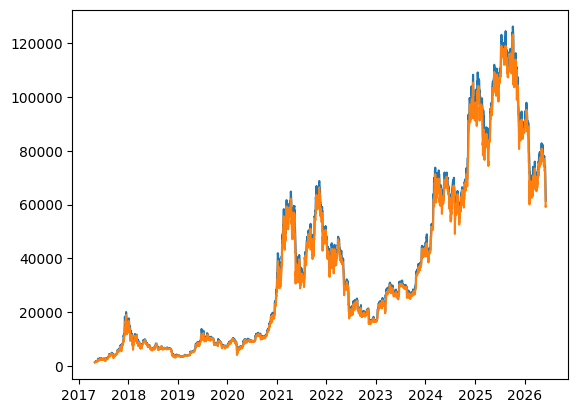

In [103]:
X = btc_data.index
Y1 = btc_data["High"]
Y2 = btc_data["Low"]
plt.plot(X,Y1)
plt.plot(X,Y2)
plt.show()
#btc_data.columns

#### The biggest fluctuations on the chart are on peaks
#### The minimum price is increasing each cycle 
#### Hypotesis - the cycle is getting longer 

In [104]:
btc_data[("High")].idxmax()

Ticker
BTC-USD   2025-10-06
dtype: datetime64[s]

In [105]:
btc_data["2020":"2023"].idxmax()

Price   Ticker 
Close   BTC-USD   2021-11-08
High    BTC-USD   2021-11-10
Low     BTC-USD   2021-11-09
Open    BTC-USD   2021-11-09
Volume  BTC-USD   2021-02-26
dtype: datetime64[s]

In [106]:
btc_data[("High")].idxmax() - btc_data["2020":"2023"].idxmax()

Price   Ticker 
Close   BTC-USD   1428 days
High    BTC-USD   1426 days
Low     BTC-USD   1427 days
Open    BTC-USD   1427 days
Volume  BTC-USD   1683 days
dtype: timedelta64[s]

In [107]:
(btc_data[("High", "BTC-USD")].idxmax() - btc_data["2020":"2023"]["High", "BTC-USD"].idxmax()).days/365

3.9068493150684933

In [108]:
btc_data["2020":"2023"].idxmax() - btc_data["2017":"2019"].idxmax()

Price   Ticker 
Close   BTC-USD   1423 days
High    BTC-USD   1424 days
Low     BTC-USD   1423 days
Open    BTC-USD   1423 days
Volume  BTC-USD    611 days
dtype: timedelta64[s]

In [109]:
(btc_data["2020":"2023"]["High", "BTC-USD"].idxmax() - btc_data["2017":"2019"]["High", "BTC-USD"].idxmax()).days/365

3.9013698630136986

In [110]:
btc_data["2024":"2026"].idxmin() - btc_data["2020":"2023"].idxmin()

Price   Ticker 
Close   BTC-USD   1411 days
High    BTC-USD   1406 days
Low     BTC-USD   1411 days
Open    BTC-USD   1407 days
Volume  BTC-USD    113 days
dtype: timedelta64[s]

In [111]:
(btc_data["2024":"2026"][("Low", "BTC-USD")].idxmin() - btc_data["2020":"2023"]["Low", "BTC-USD"].idxmin()).days/365

3.8657534246575342

In [112]:
btc_data["2020":"2023"].idxmin() - btc_data["2017":"2019"].idxmin()

Price   Ticker 
Close   BTC-USD   1046 days
High    BTC-USD   1052 days
Low     BTC-USD   1047 days
Open    BTC-USD   1051 days
Volume  BTC-USD   2330 days
dtype: timedelta64[s]

In [113]:
(btc_data["2020":"2023"]["Low", "BTC-USD"].idxmin() - btc_data["2017":"2019"]["Low", "BTC-USD"].idxmin()).days/365

2.8684931506849316

#### Peaks are regular - every 3,9 years, but bottoms are irregular, and more influenced by economic situations 

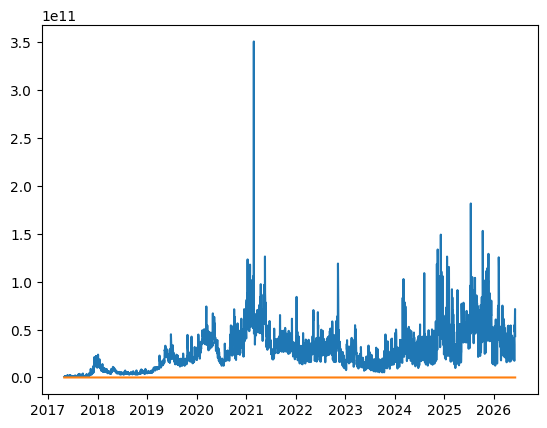

In [114]:
plt.plot(btc_data.index, btc_data["Volume"])
plt.plot(btc_data.index, btc_data["High"])

In [115]:
btc_data["2020":"2023"]["Volume", "BTC-USD"].idxmax()

Timestamp('2021-02-26 00:00:00')

In [116]:
btc_data.columns

MultiIndex([( 'Close', 'BTC-USD'),
            (  'High', 'BTC-USD'),
            (   'Low', 'BTC-USD'),
            (  'Open', 'BTC-USD'),
            ('Volume', 'BTC-USD')],
           names=['Price', 'Ticker'])

In [117]:
btc_data.loc["2021-02-26"][("High", "BTC-USD")]

np.float64(48370.78515625)

#### on February 8th 2021, Tesla announced the purchase of $1,5 billion in BTC, and that will soon accept payments in BTC - that's why volumen was high

In [118]:
btc_data["Change_%"] = btc_data["Close"].pct_change() * 100
btc_data["Change_%"].head()

Date
2017-05-01         NaN
2017-05-02    2.196115
2017-05-03    2.565357
2017-05-04    3.193101
2017-05-05    1.156289
Name: Change_%, dtype: float64

In [119]:
btc_data["Change_%"]["2017-05-02"]

np.float64(2.1961150280870756)

In [120]:
test = btc_data["Close"].pct_change() * 100
test.head()

Ticker,BTC-USD
Date,
2017-05-01,NaN
2017-05-02,2.196115
2017-05-03,2.565357
2017-05-04,3.193101
2017-05-05,1.156289


In [121]:
btc_data["Change_%"] = test
btc_data["Change_%"].head()

Date
2017-05-01         NaN
2017-05-02    2.196115
2017-05-03    2.565357
2017-05-04    3.193101
2017-05-05    1.156289
Name: Change_%, dtype: float64

<function matplotlib.pyplot.plot(*args: 'float | ArrayLike | str', scalex: 'bool' = True, scaley: 'bool' = True, data=None, **kwargs) -> 'list[Line2D]'>

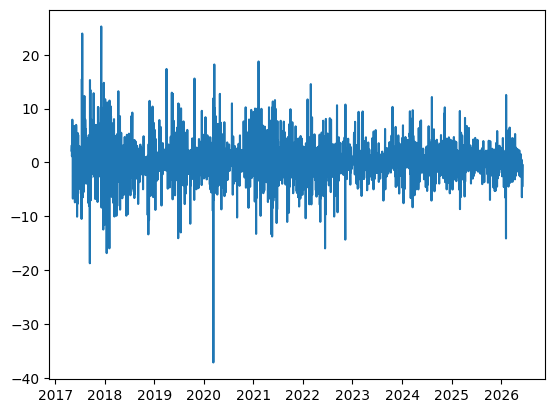

In [122]:
plt.plot(btc_data.index, btc_data["Change_%"])
plt.plot

In [123]:
btc_data["Change_%"].idxmin()

Timestamp('2020-03-12 00:00:00')

#### 12.03.2020 - Black Thursday - price dropped from $8 k to $3,8 k - COVID 19 triggered panic selling
#### BTC is starting to stabilise, less volatility than it was in 2017 :2023 - the reason: In January 2024 was issued first spot Bitcoin ETF - many big companies started to invest in Bitcoin, what has calmed the market

In [126]:
btc_data["Month"] = btc_data.index.month
btc_data["Month"]

Date
2017-05-01    5
2017-05-02    5
2017-05-03    5
2017-05-04    5
2017-05-05    5
             ..
2026-06-02    6
2026-06-03    6
2026-06-04    6
2026-06-05    6
2026-06-06    6
Name: Month, Length: 3324, dtype: int32

In [132]:
btc_data.groupby("Month")["Change_%"].agg(['min','max','mean','median']).sort_values(by="median", ascending = False)

,min,max,mean,median
Month,,,,
5,-13.766123,12.947827,0.169113,0.215860
10,-6.976852,15.576342,0.538860,0.177833
4,-8.783292,17.356014,0.324809,0.174644
3,-37.169539,18.187756,0.119943,0.124477
7,-13.009973,23.936087,0.380036,0.118286
6,-15.974726,11.569118,-0.129065,0.101207
1,-16.854801,11.733293,0.113698,0.091403
12,-12.473031,25.247169,0.218714,0.076446
11,-14.349022,11.429782,0.110650,0.066963


In [133]:
btc_data["Year"] = btc_data.index.year
btc_data["Year"]

Date
2017-05-01    2017
2017-05-02    2017
2017-05-03    2017
2017-05-04    2017
2017-05-05    2017
              ... 
2026-06-02    2026
2026-06-03    2026
2026-06-04    2026
2026-06-05    2026
2026-06-06    2026
Name: Year, Length: 3324, dtype: int32

In [135]:
btc_data[btc_data["Month"] == 11].groupby("Year")["Change_%"].agg('median')

Year
2017    2.150529
2018   -0.282737
2019   -0.414260
2020    0.183544
2021   -0.237553
2022   -0.085303
2023    0.021220
2024    0.328143
2025   -0.511669
Name: Change_%, dtype: float64

#### Popular belief says it's good to invest in BTC in November, but based on data, it was good to invest in it in 2017, after that November had better (2017 or 2024) and worse days (2025)
#### Next step is to test also 2 the best months - May and October to find out, if these two months are the best or one-offs are blurring the vision

In [136]:
btc_data[btc_data["Month"] == 5].groupby("Year")["Change_%"].agg('median')

Year
2017    2.380736
2018   -0.884162
2019    1.338835
2020    0.523321
2021   -0.784783
2022    0.207776
2023   -0.128178
2024   -0.165648
2025    0.237436
2026   -0.151319
Name: Change_%, dtype: float64

In [137]:
btc_data[btc_data["Month"] == 10].groupby("Year")["Change_%"].agg('median')

Year
2017    0.930360
2018   -0.023780
2019   -0.107805
2020    0.808458
2021    1.023789
2022   -0.470530
2023    0.252301
2024    0.036207
2025    0.129961
Name: Change_%, dtype: float64

#### May - similar to November, had better and worse days, the biggest impact has 2017, with change 2,38%, which is higher then other months. October is more stable month.

In [148]:
df_simple = pd.DataFrame({
    "Year": btc_data["Year"],
    "Month": btc_data["Month"],
    "Change_%": btc_data["Change_%"]
})
pivot = df_simple.pivot_table(index="Year", columns="Month", values= "Change_%", aggfunc="median")
pivot


Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2017,NaN,NaN,NaN,NaN,2.380736,0.761790,0.013457,1.161119,-0.311197,0.930360,2.150529,0.902001
2018,0.347080,-0.326604,-0.111574,1.044529,-0.884162,0.290921,0.517535,-0.397301,0.143444,-0.023780,-0.282737,-0.176505
2019,-0.030537,0.130181,0.125177,0.568542,1.338835,1.586765,-0.352929,0.204644,-0.309534,-0.107805,-0.414260,-0.449944
2020,0.091403,-0.258592,-0.175614,0.199533,0.523321,-0.090675,0.096808,0.278802,0.380591,0.808458,0.183544,1.270507
2021,0.238511,0.497192,0.753970,-0.448063,-0.784783,-0.015501,0.630357,-0.106040,0.679217,1.023789,-0.237553,-0.302594
2022,-0.147113,0.058313,0.342958,-0.313679,0.207776,-1.059314,-0.164629,-0.528196,-0.034602,-0.470530,-0.085303,-0.143217
2023,0.616753,-0.439486,0.005172,-0.123601,-0.128178,0.083716,-0.154060,-0.150513,-0.019590,0.252301,0.021220,0.293486
2024,-0.039001,0.889516,0.444413,-0.293337,-0.165648,-0.123970,-0.145374,-0.452452,0.377188,0.036207,0.328143,0.002627
2025,0.080148,-0.279379,-0.147270,0.355682,0.237436,0.097779,0.118286,-0.482213,0.030431,0.129961,-0.511669,0.031347
